# 09 — Interpretable description of HH regions

**Goal:** Analyze **LISA High–High (HH)** hotspots using shallow decision trees for interpretable rules.

**Two levels of analysis:**
1. **Global**: HH-vs-non-HH rules across all test samples
2. **Component**: Individual HH connected components analyzed one-vs-rest

**Outputs:** Tables in `thesis_outputs/tables/nb09/`, figures in `thesis_outputs/figures/nb09/`.

All rule learning uses **raw/readable features** (age in years, counts, etc.), not scaled versions.


In [ ]:
import sys
from pathlib import Path
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from thesis_layout import display_dataset_name, RAW_RESULTS, thesis_output_dirs

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Interpretable rules module
from analysis.io_utils import get_run_dirs
from analysis.rule_extraction import (
    load_seed_data,
    recurring_rules_by_method_label,
    rule_feature_frequency_across_seeds,
    compute_global_rules_all,
    compute_component_rules_all,
)

RESULTS_DIR = RAW_RESULTS
TABLE_DIR, FIG_DIR = thesis_output_dirs("nb09")

print(f"Results directory: {RESULTS_DIR}")
print(f"Tables output to: {TABLE_DIR}")
print(f"Figures output to: {FIG_DIR}")
FORCE_RECOMPUTE = False
CACHE_VERSION = "v1"
CACHE_DIR = ROOT / "thesis_outputs" / "cache" / "notebooks"
CACHE_DIR.mkdir(parents=True, exist_ok=True)




Results directory: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\results
Tables output to: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb09
Figures output to: C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\figures\nb09


## Configuration

Analysis parameters: seed range, dataset, tree hyperparameters, component size thresholds.


In [ ]:
# Analysis parameters
OUTER_SEEDS = list(range(10))
SEED_FOR_FIGURES = 0
dataset_name = "compas"
K = 25  # Rashomon set size

# Tree hyperparameters
TREE_MAX_DEPTH = 3
TREE_MIN_SAMPLES_LEAF_GLOBAL = 10
TREE_MIN_SAMPLES_LEAF_COMPONENT = 5

# Component filtering
MIN_COMPONENT_SIZE = 20

# Bootstrap and permutation parameters
N_BOOTSTRAP_OOB = 200
N_PERMUTATIONS = 500

print(f"Dataset: {dataset_name}")
print(f"Outer seeds: {OUTER_SEEDS}")
print(f"Min component size: {MIN_COMPONENT_SIZE}")
print(f"Trees: max_depth={TREE_MAX_DEPTH}, min_samples_leaf (global)={TREE_MIN_SAMPLES_LEAF_GLOBAL}, (component)={TREE_MIN_SAMPLES_LEAF_COMPONENT}")

SEEDS = [
    int(p.name.split("=")[1])
    for p in get_run_dirs(RESULTS_DIR / dataset_name)
]

print(f"Available seeds for {dataset_name}: {SEEDS}")

Dataset: compas
Outer seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Min component size: 20
Trees: max_depth=3, min_samples_leaf (global)=10, (component)=5


## Global HH-vs-non-HH rules across seeds

For each seed: fit decision tree on raw features to distinguish HH from non-HH.
Extract positive-leaf rules with support, purity, recall, lift metrics.


In [ ]:
# Run global HH-vs-non-HH analysis for all seeds
global_rules_path = CACHE_DIR / f"nb09_global_rules_{dataset_name}_{CACHE_VERSION}.parquet"

if not FORCE_RECOMPUTE and global_rules_path.is_file():
    global_rules_all = pd.read_parquet(global_rules_path)

    # Recompute auxiliary objects that are not stored in the parquet cache.
    _, global_metadata_by_seed, plot_bundle = compute_global_rules_all(
        RESULTS_DIR,
        dataset_name=dataset_name,
        seeds=SEEDS,
        K=K,
        min_component_size=MIN_COMPONENT_SIZE,
        tree_max_depth=TREE_MAX_DEPTH,
        min_samples_leaf_global=TREE_MIN_SAMPLES_LEAF_GLOBAL,
        seed_for_figures=SEED_FOR_FIGURES,
    )
else:
    global_rules_all, global_metadata_by_seed, plot_bundle = compute_global_rules_all(
        RESULTS_DIR,
        dataset_name=dataset_name,
        seeds=SEEDS,
        K=K,
        min_component_size=MIN_COMPONENT_SIZE,
        tree_max_depth=TREE_MAX_DEPTH,
        min_samples_leaf_global=TREE_MIN_SAMPLES_LEAF_GLOBAL,
        seed_for_figures=SEED_FOR_FIGURES,
    )

    global_rules_all.to_parquet(global_rules_path, index=False)

seeds_completed = sorted(global_rules_all["outer_seed"].unique().tolist())

print(f"\nCompleted {len(seeds_completed)} seeds: {seeds_completed}")
print(f"Global rules table: {len(global_rules_all)} rows")

[seed 0] n_test=1443, n_hh=68, rules=6


[seed 1] n_test=1443, n_hh=138, rules=6


[seed 2] n_test=1443, n_hh=122, rules=8


[seed 3] n_test=1443, n_hh=271, rules=7


[seed 4] n_test=1443, n_hh=54, rules=6


[seed 5] n_test=1443, n_hh=71, rules=5


[seed 6] n_test=1443, n_hh=146, rules=6


[seed 7] n_test=1443, n_hh=175, rules=8


[seed 8] n_test=1443, n_hh=197, rules=6


[seed 9] n_test=1443, n_hh=47, rules=4

Completed 10 seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Global rules table: 62 rows


## Component-level HH rules across seeds

For each seed and each HH component with size >= MIN_COMPONENT_SIZE:
- Fit tree to distinguish component (positive) from non-component (negative)
- Extract positive-leaf rules with support, component_purity, component_recall, etc.
- Compute mean pointwise variance within and outside component


In [ ]:
# Run component-level analysis for all seeds
component_rules_path = CACHE_DIR / f"nb09_component_rules_{dataset_name}_{CACHE_VERSION}.parquet"
component_summary_path = CACHE_DIR / f"nb09_component_summary_{dataset_name}_{CACHE_VERSION}.parquet"

if (
    not FORCE_RECOMPUTE
    and component_rules_path.is_file()
    and component_summary_path.is_file()
):
    component_rules_all = pd.read_parquet(component_rules_path)
    component_summary_all = pd.read_parquet(component_summary_path)
else:
    component_rules_all, component_summary_all = compute_component_rules_all(
        RESULTS_DIR,
        dataset_name=dataset_name,
        seeds=SEEDS,
        K=K,
        min_component_size=MIN_COMPONENT_SIZE,
        tree_max_depth=TREE_MAX_DEPTH,
        min_samples_leaf_component=TREE_MIN_SAMPLES_LEAF_COMPONENT,
    )
    component_rules_all.to_parquet(component_rules_path, index=False)
    component_summary_all.to_parquet(component_summary_path, index=False)

print(f"Component rules: {len(component_rules_all)} rows")
print(f"Component summaries: {len(component_summary_all)} rows")


[seed 0] 1 components kept (of 1 total)


[seed 1] 2 components kept (of 2 total)


[seed 2] 1 components kept (of 3 total)


[seed 3] 1 components kept (of 1 total)


[seed 4] 1 components kept (of 3 total)


[seed 5] 2 components kept (of 3 total)


[seed 6] 3 components kept (of 4 total)


[seed 7] 2 components kept (of 2 total)


[seed 8] 3 components kept (of 3 total)


[seed 9] 1 components kept (of 1 total)
Component rules: 60 rows
Component summaries: 17 rows


## Minimal thesis-ready figures

1. Global HH-vs-non-HH rules: support vs purity
2. Component rules: support vs component_purity
3. PCA with HH components (representative seed)


Saved: rules_support_purity_compas.pdf


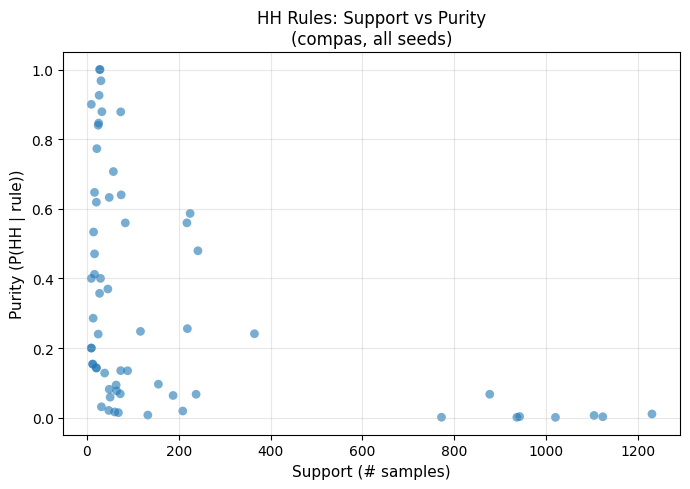

In [6]:
# Figure 1: Global HH rules - support vs purity
df_global = global_rules_all.dropna(subset=["support", "purity"])

fig, ax = plt.subplots(figsize=(7, 5))
scatter = ax.scatter(
    df_global["support"],
    df_global["purity"],
    alpha=0.6,
    s=40,
    edgecolors="none",
)
ax.set_xlabel("Support (# samples)", fontsize=11)
ax.set_ylabel("Purity (P(HH | rule))", fontsize=11)
ax.set_title(f"HH Rules: Support vs Purity\n({display_dataset_name(dataset_name)}, all seeds)", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / f"rules_support_purity_{dataset_name}.pdf", dpi=300, bbox_inches='tight')
print(f"Saved: rules_support_purity_{dataset_name}.pdf")
plt.show()


Saved: component_rules_support_purity_compas.pdf


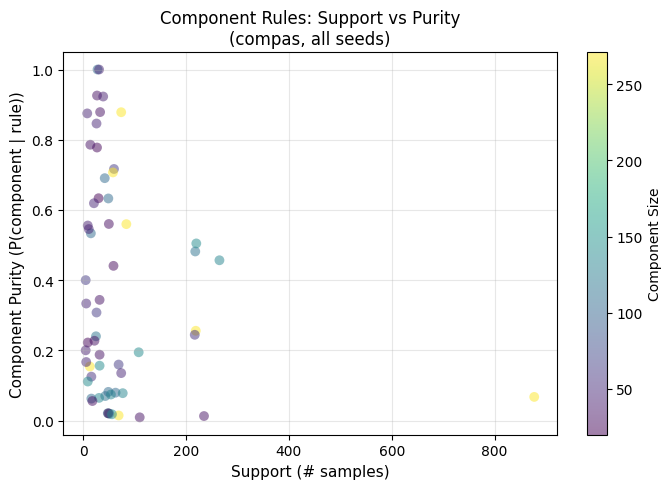

In [7]:
# Figure 2: Component rules - support vs component_purity
if len(component_rules_all) > 0:
    df_comp = component_rules_all.dropna(subset=["support", "component_purity"])
    
    fig, ax = plt.subplots(figsize=(7, 5))
    scatter = ax.scatter(
        df_comp["support"],
        df_comp["component_purity"],
        s=50,
        alpha=0.5,
        c=df_comp.get("component_size", 20),
        cmap="viridis",
        edgecolors="none",
    )
    ax.set_xlabel("Support (# samples)", fontsize=11)
    ax.set_ylabel("Component Purity (P(component | rule))", fontsize=11)
    ax.set_title(f"Component Rules: Support vs Purity\n({display_dataset_name(dataset_name)}, all seeds)", fontsize=12)
    cbar = plt.colorbar(scatter, ax=ax, label="Component Size")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"component_rules_support_purity_{dataset_name}.pdf", dpi=300, bbox_inches='tight')
    print(f"Saved: component_rules_support_purity_{dataset_name}.pdf")
    plt.show()
else:
    print("No component rules to plot")


Saved: pca_hh_components_compas_seed0.pdf


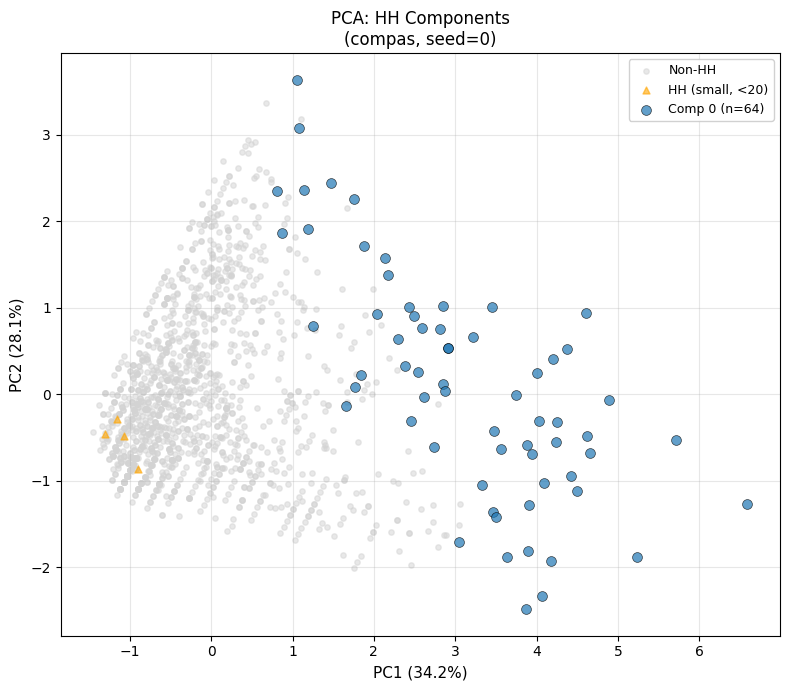

In [8]:
# Figure 3: PCA with HH components (representative seed)
if plot_bundle is None:
    print("No plot_bundle available for figures")
else:
    pb = plot_bundle
    X_raw = pb["X_raw"]
    X_transformed = pb["X_transformed"]
    HH_mask = pb["HH_mask"]
    components_kept = pb["components_kept"]
    
    # PCA on transformed features
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X_transformed)
    
    fig, ax = plt.subplots(figsize=(8, 7))
    
    # Background: all non-HH
    ax.scatter(
        X_pca[~HH_mask, 0],
        X_pca[~HH_mask, 1],
        c="lightgray",
        s=15,
        alpha=0.5,
        label="Non-HH",
        zorder=1,
    )
    
    # HH non-component (small or < MIN_COMPONENT_SIZE)
    all_hh_idx = np.where(HH_mask)[0]
    small_hh = []
    for idx in all_hh_idx:
        in_kept = False
        for comp_indices in components_kept.values():
            if idx in comp_indices:
                in_kept = True
                break
        if not in_kept:
            small_hh.append(idx)
    
    if small_hh:
        ax.scatter(
            X_pca[small_hh, 0],
            X_pca[small_hh, 1],
            c="orange",
            s=25,
            alpha=0.6,
            marker="^",
            label=f"HH (small, <{MIN_COMPONENT_SIZE})",
            zorder=2,
        )
    
    # Kept components (different colors)
    colors = plt.cm.tab10(np.linspace(0, 1, min(10, len(components_kept))))
    for color_idx, (comp_id, comp_indices) in enumerate(sorted(
        components_kept.items(),
        key=lambda x: len(x[1]),
        reverse=True
    )[:10]):
        ax.scatter(
            X_pca[comp_indices, 0],
            X_pca[comp_indices, 1],
            c=[colors[color_idx]],
            s=50,
            alpha=0.7,
            label=f"Comp {comp_id} (n={len(comp_indices)})",
            edgecolors="black",
            linewidth=0.5,
            zorder=3,
        )
    
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})", fontsize=11)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})", fontsize=11)
    ax.set_title(f"PCA: HH Components\n({display_dataset_name(dataset_name)}, seed={pb['seed']})", fontsize=12)
    ax.legend(loc="best", fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"pca_hh_components_{dataset_name}_seed{pb['seed']}.pdf", dpi=300, bbox_inches='tight')
    print(f"Saved: pca_hh_components_{dataset_name}_seed{pb['seed']}.pdf")
    plt.show()


## Feature frequency and recurring rules

Identify features that frequently appear across seeds and rules.


In [9]:
# Compute global rule feature frequency
global_feature_freq = rule_feature_frequency_across_seeds(
    global_rules_all,
    last_feature_names := global_metadata_by_seed[seeds_completed[0]].get("feature_names", []),
)

# Compute recurring rules (appear in multiple seeds)
global_recurring = recurring_rules_by_method_label(global_rules_all, min_seeds=3)

# Component feature frequency
if len(component_rules_all) > 0:
    comp_feature_freq = rule_feature_frequency_across_seeds(
        component_rules_all,
        last_feature_names,
    )
else:
    comp_feature_freq = pd.DataFrame()

print(f"Global feature frequency: {len(global_feature_freq)} distinct features")
print(f"Global recurring rules (in >=3 seeds): {len(global_recurring)}")
print(f"Component feature frequency: {len(comp_feature_freq)} distinct features")


Global feature frequency: 8 distinct features
Global recurring rules (in >=3 seeds): 0
Component feature frequency: 9 distinct features


Plotting raw feature region for age and priors_count


Saved: rule_region_age_priors_compas.pdf


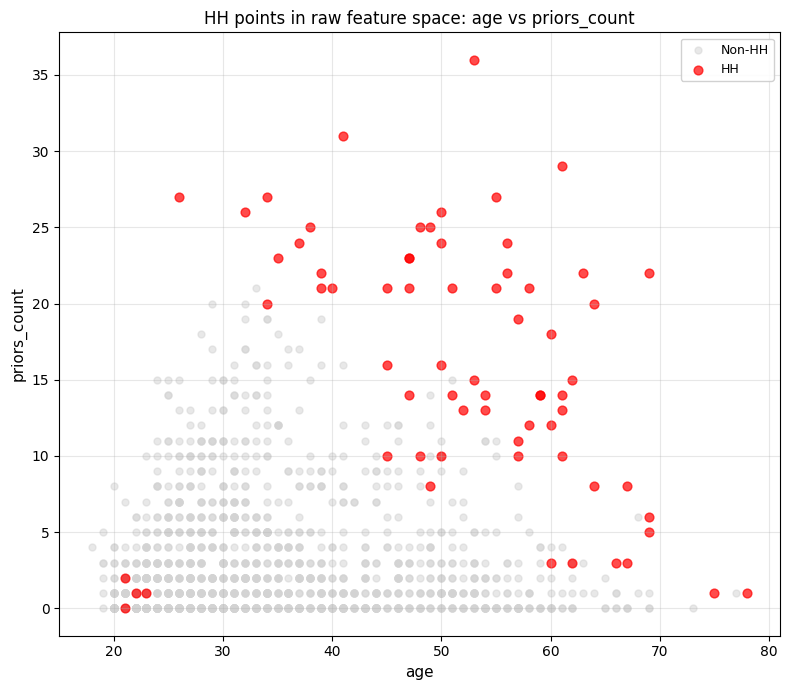

In [10]:
import matplotlib.patches as patches

# Figure 4: Raw feature-space visualization for top rule features
if len(global_feature_freq) == 0:
    print("No frequent rule features available for raw feature visualization")
else:
    top_features = global_feature_freq["feature"].tolist()
    if "age" in top_features and "priors_count" in top_features:
        x_feature, y_feature = "age", "priors_count"
    elif len(top_features) >= 2:
        x_feature, y_feature = top_features[:2]
    else:
        print("Not enough frequent rule features to plot")
        x_feature = y_feature = None

    if x_feature is None or y_feature is None:
        pass
    else:
        print(f"Plotting raw feature region for {x_feature} and {y_feature}")

        if plot_bundle is None:
            print("No representative seed data available for raw feature plot")
        else:
            X_raw = plot_bundle["X_raw"]
            HH_mask = plot_bundle["HH_mask"]
            df_plot = X_raw[[x_feature, y_feature]].copy()
            df_plot["HH"] = HH_mask

            fig, ax = plt.subplots(figsize=(8, 7))
            ax.scatter(
                df_plot.loc[~df_plot["HH"], x_feature],
                df_plot.loc[~df_plot["HH"], y_feature],
                c="lightgray",
                s=25,
                alpha=0.5,
                label="Non-HH",
            )
            ax.scatter(
                df_plot.loc[df_plot["HH"], x_feature],
                df_plot.loc[df_plot["HH"], y_feature],
                c="red",
                s=40,
                alpha=0.7,
                label="HH",
            )

            anno_rule = None
            for _, rule in global_rules_all.iterrows():
                if x_feature in str(rule.get("rule_features", "")) and y_feature in str(rule.get("rule_features", "")):
                    anno_rule = str(rule["rule_text"])
                    break

            if anno_rule is not None and " AND " in anno_rule:
                bounds = {x_feature: [None, None], y_feature: [None, None]}
                for term in anno_rule.split(" AND "):
                    if term.startswith(f"{x_feature} <="):
                        bounds[x_feature][1] = float(term.split("<=")[1].strip())
                    elif term.startswith(f"{x_feature} >"):
                        bounds[x_feature][0] = float(term.split(">")[1].strip())
                    elif term.startswith(f"{y_feature} <="):
                        bounds[y_feature][1] = float(term.split("<=")[1].strip())
                    elif term.startswith(f"{y_feature} >"):
                        bounds[y_feature][0] = float(term.split(">")[1].strip())

                if all(v is not None for v in [bounds[x_feature][0], bounds[x_feature][1], bounds[y_feature][0], bounds[y_feature][1]]):
                    rect = patches.Rectangle(
                        (bounds[x_feature][0], bounds[y_feature][0]),
                        bounds[x_feature][1] - bounds[x_feature][0],
                        bounds[y_feature][1] - bounds[y_feature][0],
                        linewidth=2,
                        edgecolor="blue",
                        facecolor="none",
                        linestyle="--",
                        label=f"Rule region: {anno_rule}",
                    )
                    ax.add_patch(rect)

            ax.set_xlabel(x_feature, fontsize=11)
            ax.set_ylabel(y_feature, fontsize=11)
            ax.set_title(f"HH points in raw feature space: {x_feature} vs {y_feature}", fontsize=12)
            ax.legend(loc="best", fontsize=9, framealpha=0.9)
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            if x_feature == 'age' and y_feature == 'priors_count':
                output_name = f"rule_region_age_priors_{dataset_name}.pdf"
            else:
                output_name = f"rule_region_{x_feature}_{y_feature}_{dataset_name}.pdf"
            plt.savefig(FIG_DIR / output_name, dpi=300, bbox_inches='tight')
            print(f"Saved: {output_name}")
            plt.show()

In [11]:
# Export all tables

# Ensure output directories exist
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Global rules tables
print("Saving global rules tables...")
global_rules_all.to_csv(TABLE_DIR / f"rules_summary_{dataset_name}.csv", index=False)
global_feature_freq.to_csv(TABLE_DIR / f"rule_feature_frequency_{dataset_name}.csv", index=False)
global_recurring.to_csv(TABLE_DIR / f"rules_recurring_across_seeds_{dataset_name}.csv", index=False)

# Component-level tables
print("Saving component tables...")
if len(component_rules_all) > 0:
    component_rules_all.to_csv(TABLE_DIR / f"component_rules_summary_{dataset_name}.csv", index=False)
    comp_feature_freq.to_csv(TABLE_DIR / f"component_feature_frequency_{dataset_name}.csv", index=False)
    component_summary_all.to_csv(TABLE_DIR / f"component_summary_{dataset_name}.csv", index=False)

print(f"\n✓ Tables saved to {TABLE_DIR}")
print(f"✓ Figures saved to {FIG_DIR}")

# Summary statistics
print(f"\nExport Summary:")
print(f"  Global rules: {len(global_rules_all)} rows")
print(f"  Component rules: {len(component_rules_all)} rows")
print(f"  Component summaries: {len(component_summary_all)} rows")
print(f"  Seeds completed: {len(seeds_completed)}")


Saving global rules tables...
Saving component tables...

✓ Tables saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\tables\nb09
✓ Figures saved to C:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\thesis_outputs\figures\nb09

Export Summary:
  Global rules: 62 rows
  Component rules: 60 rows
  Component summaries: 17 rows
  Seeds completed: 10


## Sanity checks

Validate outputs and check for completeness.


In [ ]:
# Sanity checks
print("=== SANITY CHECKS ===\n")

# Check 1: Completed seeds
print(f"✓ Completed seeds: {seeds_completed}")
assert len(seeds_completed) > 0, "No seeds completed!"
print(f"  Expected: 10, Actual: {len(seeds_completed)}\n")

# Check 2: HH counts per seed
print(f"✓ HH point counts per seed:")
for seed in seeds_completed:
    n_hh = global_metadata_by_seed[seed]["n_hh"]
    n_total = global_metadata_by_seed[seed]["n_total"]
    print(f"  Seed {seed}: {n_hh}/{n_total} HH points ({100*n_hh/n_total:.1f}%)")
print()

# Check 3: Component analysis
print(f"✓ Component statistics:")
for seed in seeds_completed:
    run_dir = RESULTS_DIR / dataset_name / f"seed={seed}"
    data = load_seed_data(run_dir, dataset_name, K=K, seed=seed, min_component_size=MIN_COMPONENT_SIZE)
    n_all = len(data["components_all"])
    n_kept = len(data["components_kept"])
    print(f"  Seed {seed}: {n_kept} kept components (of {n_all} total, min_size={MIN_COMPONENT_SIZE})")
print()

# Check 4: Table column presence
print(f"✓ Required columns check:")
required_global = ["outer_seed", "rule_text", "support", "purity"]
for col in required_global:
    assert col in global_rules_all.columns or col in global_rules_all.columns.str.lower(), f"Missing global column: {col}"
print(f"  Global rules table: OK ({', '.join(required_global)})")

if len(component_rules_all) > 0:
    required_comp = ["outer_seed", "component_id", "component_size", "support"]
    for col in required_comp:
        assert col in component_rules_all.columns, f"Missing component column: {col}"
    print(f"  Component rules table: OK ({', '.join(required_comp)})")
print()

# Check 5: Files exist
print(f"✓ Output files check:")
files_to_check = [
    TABLE_DIR / f"rules_summary_{dataset_name}.csv",
    TABLE_DIR / f"rule_feature_frequency_{dataset_name}.csv",
    FIG_DIR / f"rules_support_purity_{dataset_name}.pdf",
]
if len(component_rules_all) > 0:
    files_to_check.extend([
        TABLE_DIR / f"component_rules_summary_{dataset_name}.csv",
        TABLE_DIR / f"component_summary_{dataset_name}.csv",
    ])

for fpath in files_to_check:
    exists = "✓" if fpath.exists() else "✗"
    print(f"  {exists} {fpath.name}")

print("\n✓ All sanity checks passed! Notebook ready for thesis.")


=== SANITY CHECKS ===

✓ Completed seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Expected: 10, Actual: 10

✓ HH point counts per seed:
  Seed 0: 68/1443 HH points (4.7%)
  Seed 1: 138/1443 HH points (9.6%)
  Seed 2: 122/1443 HH points (8.5%)
  Seed 3: 271/1443 HH points (18.8%)
  Seed 4: 54/1443 HH points (3.7%)
  Seed 5: 71/1443 HH points (4.9%)
  Seed 6: 146/1443 HH points (10.1%)
  Seed 7: 175/1443 HH points (12.1%)
  Seed 8: 197/1443 HH points (13.7%)
  Seed 9: 47/1443 HH points (3.3%)

✓ Component statistics:


  Seed 0: 1 kept components (of 1 total, min_size=20)


  Seed 1: 2 kept components (of 2 total, min_size=20)


  Seed 2: 1 kept components (of 3 total, min_size=20)


  Seed 3: 1 kept components (of 1 total, min_size=20)


...

  Seed 5: 2 kept components (of 3 total, min_size=20)


  Seed 6: 3 kept components (of 4 total, min_size=20)


  Seed 7: 2 kept components (of 2 total, min_size=20)


  Seed 8: 3 kept components (of 3 total, min_size=20)


  Seed 9: 1 kept components (of 1 total, min_size=20)

✓ Required columns check:
  Global rules table: OK (outer_seed, rule_text, support, purity)
  Component rules table: OK (outer_seed, component_id, component_size, support)

✓ Output files check:
  ✓ rules_summary_compas.csv
  ✓ rule_feature_frequency_compas.csv
  ✓ rules_support_purity_compas.pdf
  ✓ component_rules_summary_compas.csv
  ✓ component_summary_compas.csv

✓ All sanity checks passed! Notebook ready for thesis.
